Импорт необходимых модулей:

In [1]:
import imp
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

import numpy as np
from PIL import Image 

from cmath import isclose
import math

import multiprocessing
from joblib import Parallel, delayed
# from math import isqrt

import platform
import subprocess

/tmp/ipykernel_4652/4101565150.py:1: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp


### Генерируем точки + строим графики и изображения

In [2]:
#total_points_sqrt = 3163
total_points_sqrt = 3163
total_points = total_points_sqrt * total_points_sqrt

print(total_points)

10004569


Билдим проект через cmake

In [3]:
subprocess.run(['cmake', '.', '-B', 'bin/', '-G', 'Ninja', '-D', 'CMAKE_BUILD_TYPE=Release'])
subprocess.run(['cmake', '--build', 'bin/'])

[1/6] Building C object CMakeFiles/generators-JUPITER_NOTEBOOK.dir/generators.c.o
FAILED: CMakeFiles/generators-JUPITER_NOTEBOOK.dir/generators.c.o 
/bin/cc   -O3 -DNDEBUG -MD -MT CMakeFiles/generators-JUPITER_NOTEBOOK.dir/generators.c.o -MF CMakeFiles/generators-JUPITER_NOTEBOOK.dir/generators.c.o.d -o CMakeFiles/generators-JUPITER_NOTEBOOK.dir/generators.c.o -c /home/joel/Development/practice/nikulin/cpp/2_pi_monte_carlo/histogram2/generators.c
cc1: fatal error: /home/joel/Development/practice/nikulin/cpp/2_pi_monte_carlo/histogram2/generators.c: No such file or directory
compilation terminated.
[2/6] Building CXX object CMakeFiles/samples-JUPITER_NOTEBOOK.dir/samples.cpp.o
FAILED: CMakeFiles/samples-JUPITER_NOTEBOOK.dir/samples.cpp.o 
/bin/c++   -O3 -DNDEBUG -MD -MT CMakeFiles/samples-JUPITER_NOTEBOOK.dir/samples.cpp.o -MF CMakeFiles/samples-JUPITER_NOTEBOOK.dir/samples.cpp.o.d -o CMakeFiles/samples-JUPITER_NOTEBOOK.dir/samples.cpp.o -c /home/joel/Development/practice/nikulin/cpp/2_

CMake Error: The current CMakeCache.txt directory /home/joel/Development/practice/nikulin/cpp/2_pi_monte_carlo/histogram/bin/CMakeCache.txt is different than the directory /home/joel/Development/practice/nikulin/cpp/2_pi_monte_carlo/histogram2/bin where CMakeCache.txt was created. This may result in binaries being created in the wrong place. If you are not sure, reedit the CMakeCache.txt
CMake Error: The source "/home/joel/Development/practice/nikulin/cpp/2_pi_monte_carlo/histogram/CMakeLists.txt" does not match the source "/home/joel/Development/practice/nikulin/cpp/2_pi_monte_carlo/histogram2/CMakeLists.txt" used to generate cache.  Re-run cmake with a different source directory.
CMake Error: The current CMakeCache.txt directory /home/joel/Development/practice/nikulin/cpp/2_pi_monte_carlo/histogram/bin/CMakeCache.txt is different than the directory /home/joel/Development/practice/nikulin/cpp/2_pi_monte_carlo/histogram2/bin where CMakeCache.txt was created. This may result in binaries

CompletedProcess(args=['cmake', '--build', 'bin/'], returncode=1)

Запускаем генерацию точек

In [4]:
if platform.system() == 'Windows':
    out = subprocess.check_output( ".\\bin\\ResearchGenerators.exe --xs64 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( ".\\bin\\ResearchGenerators.exe --xs1024 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( ".\\bin\\ResearchGenerators.exe --mt19937 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( ".\\bin\\ResearchGenerators.exe --rand " + str(total_points), shell=True, text=True )
    print(out)
else:
    out = subprocess.check_output( "./bin/ResearchGenerators --xs64 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "./bin/ResearchGenerators --xs1024 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "./bin/ResearchGenerators --mt19937 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "./bin/ResearchGenerators --rand " + str(total_points), shell=True, text=True )
    print(out)

Elapsed time for generator: "xs64"; Total values: 10004569	 --- 3637669 microseconds

Elapsed time for generator: "xs1024"; Total values: 10004569	 --- 3468385 microseconds

Elapsed time for generator: "mt19937"; Total values: 10004569	 --- 3483422 microseconds

Elapsed time for generator: "rand"; Total values: 10004569	 --- 3526361 microseconds



Подгружаем сгенерированные выборки:

In [5]:
x64      = pd.read_csv("xs64.csv")
x1024    = pd.read_csv("xs1024.csv")
mt19937  = pd.read_csv("mt19937.csv")
rand     = pd.read_csv("rand.csv")

Вывод первых 5-ти значий со сгенерированного файла:

In [6]:
x64.head()

,randoms
0,0.045651
1,0.823337
2,0.104083
3,0.557747
4,0.022834


Описательная статистика:

In [7]:
x64['randoms'].describe()

count    1.000457e+07
mean     5.002635e-01
std      2.886939e-01
min      3.092550e-08
25%      2.502440e-01
50%      5.004350e-01
75%      7.504340e-01
max      1.000000e+00
Name: randoms, dtype: float64

Строим гистограммы:

In [8]:
bins = 1000
bins_ranges = np.arange(start=0, stop=1, step=1 / bins)

In [9]:
hist_x64, bins_ranges = np.histogram(x64.to_numpy(), bins_ranges)
hist_x1024, bins_ranges = np.histogram(x1024.to_numpy(), bins_ranges)
hist_mt19937, bins_ranges = np.histogram(mt19937.to_numpy(), bins_ranges)
hist_rand, bins_ranges = np.histogram(rand.to_numpy(), bins_ranges)

(9627.0, 10289.0)

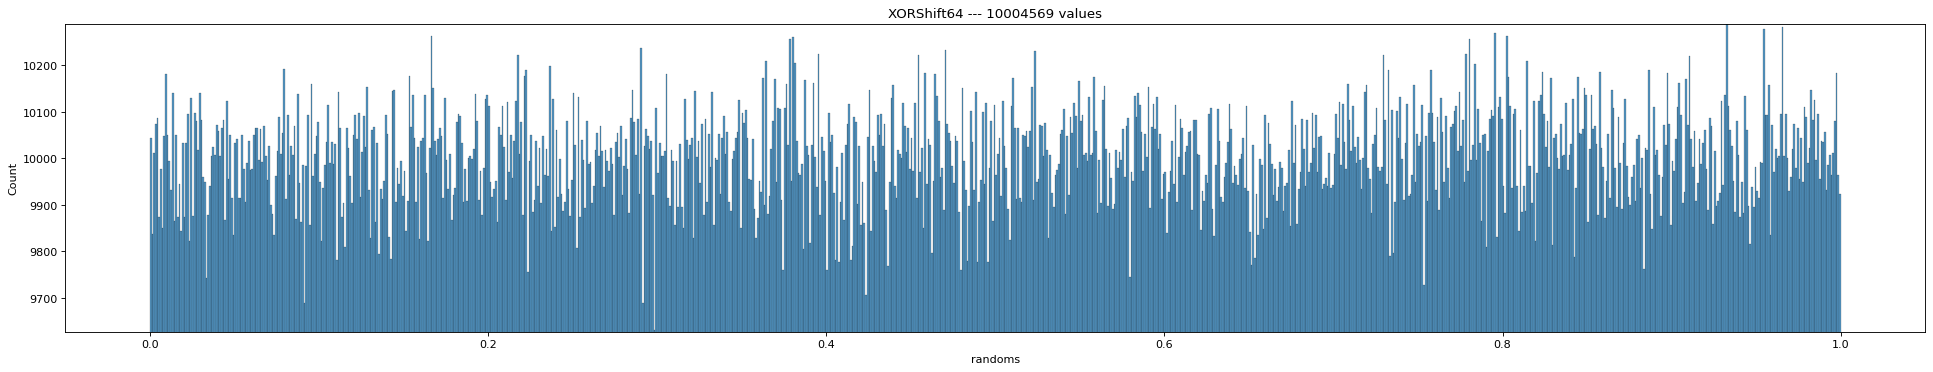

In [10]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=x64, x="randoms", bins=bins).set(title='XORShift64 --- ' + str(total_points) + ' values')

plt.ylim(bottom=np.min(hist_x64), top=np.max(hist_x64))

In [11]:
data = 255 * np.array(x64)
data = np.uint8(data)

In [12]:
data.shape

(10004569, 1)

In [13]:
data = data.reshape(total_points_sqrt, total_points_sqrt)
print(data)

[[ 11 209  26 ...  55 237  69]
 [ 26 201 107 ... 115  54 213]
 [147   1 179 ... 227  18  64]
 ...
 [ 10 134 254 ...  39 223  78]
 [233 237 235 ...  47 188  77]
 [195 126 116 ...  43  93 188]]


In [14]:
data.shape

(3163, 3163)

In [15]:
img = Image.fromarray(data, 'L')
img.save('XORShift64_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(9708.0, 10331.0)

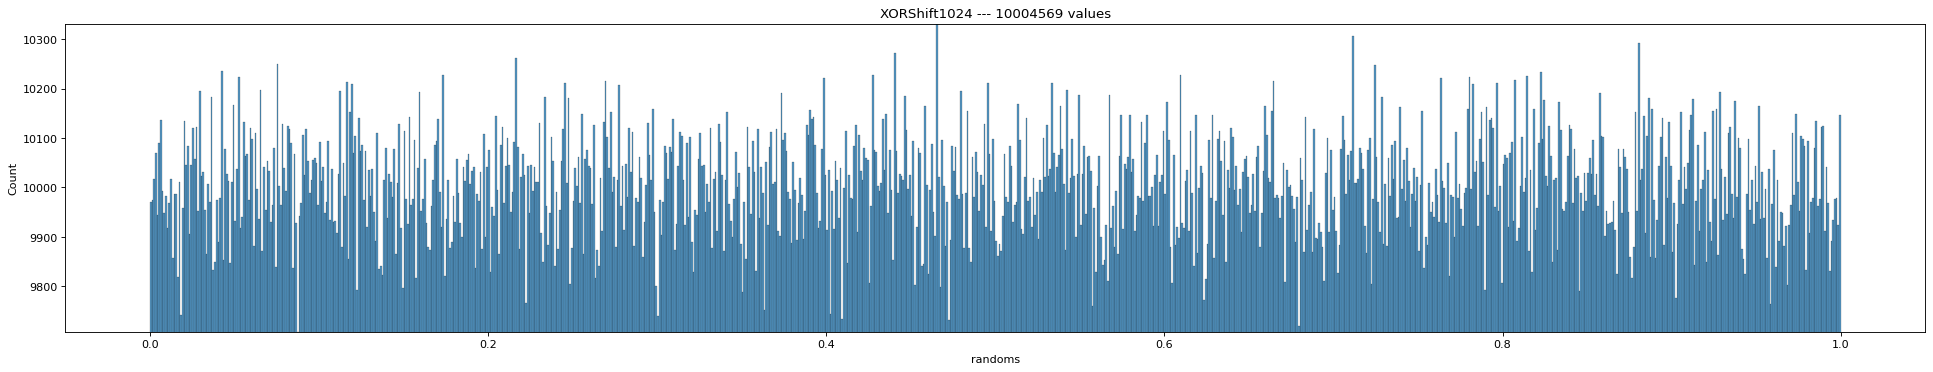

In [16]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=x1024, x="randoms", bins=bins).set(title='XORShift1024 --- ' + str(total_points) + ' values')

plt.ylim(bottom=np.min(hist_x1024), top=np.max(hist_x1024))

In [17]:
data = 255 * np.array(x1024)
data = np.uint8(data)
data = data.reshape(total_points_sqrt, total_points_sqrt)

In [18]:
img = Image.fromarray(data, 'L')
img.save('XORShift1024_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(9638.0, 10350.0)

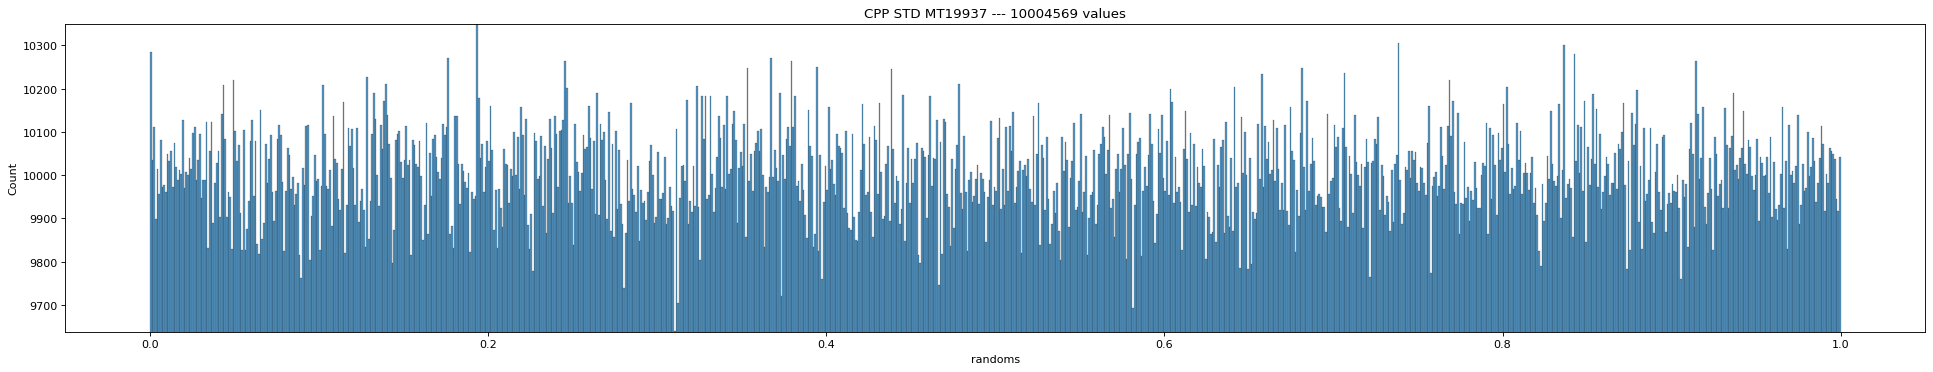

In [19]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=mt19937, x="randoms", bins=bins).set(title='CPP STD MT19937 --- ' + str(total_points) + ' values')

plt.ylim(bottom=np.min(hist_mt19937), top=np.max(hist_mt19937))

In [20]:
data = 255 * np.array(mt19937)
data = np.uint8(data)
data = data.reshape(total_points_sqrt, total_points_sqrt)

In [21]:
img = Image.fromarray(data, 'L')
img.save('MT19937_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(9632.0, 10382.0)

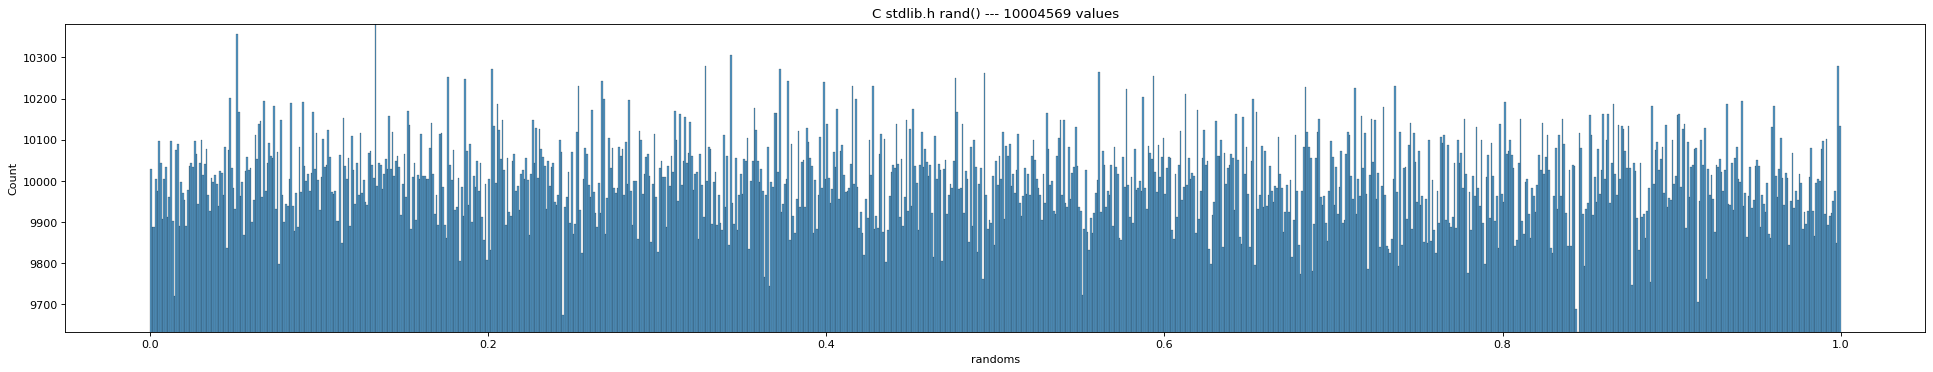

In [22]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=rand, x="randoms", bins=bins).set(title='C stdlib.h rand() --- ' + str(total_points) + ' values')

plt.ylim(bottom=np.min(hist_rand), top=np.max(hist_rand))

In [23]:
data = 255 * np.array(rand)
data = np.uint8(data)
data = data.reshape(total_points_sqrt, total_points_sqrt)

In [24]:
img = Image.fromarray(data, 'L')
img.save('CSTDLibRand_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

## Метрики качества

In [25]:
# метод проверки, что хотя бы одно сгенерированное число из выборки есть в диапазоне [left..right), 
# ИДЕАЛЬНЫЙ ГЕНЕРАТОР выдаст ОДНО ЧИСЛО на ОДИН ДИАПАЗОН
def parallel_task(left, step, generated_values):
    right = left + step # next элемент (правый сосед, как граница диапазона) из массива expected_values

    for generated in generated_values:
        if (isclose(generated, left) or generated > left) and generated < right:
            # если сгенерированное число (generated) >= левой границе диапазона (left) и строго меньше правой границы (right) ---> выдать единицу
            return 1
                    
    return 0

# метод проверки качества сгенерированных значений, два типа проверки 'by-sum' -- быстрее и 'by-element' -- медленнее (но точнее)
def get_quality_of_values(generated_values, type='by-sum'):
    size = len(generated_values)

    # массив ожидаемых значений [0..1)
    range_step = 1.0 / size
    expected_values = np.arange(start=0, stop=1, step=range_step)    # ожидаемые значения ИДЕАЛЬНОГО ГЕНЕРАТОРА [0, 0.001, 0.002, ..., 1)

    generated_values = generated_values.to_numpy()
    error = None

    print(f'Expected values: {expected_values}')
    print(f'Generated values: {generated_values}')

    # проверка схожести суммы идеальных значений с суммой реальных значений
    # по сумме
    if type == 'by-sum':

        ideal_sum = expected_values.sum()
        real_sum = generated_values.sum()

        # отклонение от необходимой суммы в процентах
        error = abs( ideal_sum - real_sum ) 
        error /= ideal_sum

    # по элементно
    elif type == 'by-element':

        # parallel loop
        num_cores = multiprocessing.cpu_count()
        results = Parallel(n_jobs=num_cores)(delayed(parallel_task)(ideal, range_step, generated_values) for ideal in expected_values)

        # реальное количество диапазонов, в которых есть сгенерированные числа (В ИДЕАЛЕ, это число будет равно КОЛИЧЕСТВУ СГЕНЕРИРОВАННЫХ ЧИСЕЛ)
        good_elements = np.array(results).sum()

        error = 1 - good_elements / size
        print(f'Good elements: {good_elements}')
        print(f'Total generated values: {size}\nError: {error}')

    else:
        raise ValueError("Wrong type!")

    return 1 - error    # вывод качества с учётом ошибки ---> 1 - идеальный генератор, 0 - плохой генератор

Параметры для проверки качества:

In [26]:
#type = 'by-element'
type = 'by-sum'

Метрика качества для XorShift64:

In [27]:
quality = get_quality_of_values(x64, type)
print(f'XorShift64 Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.0456506]
 [0.823337 ]
 [0.104083 ]
 ...
 [0.171183 ]
 [0.366444 ]
 [0.73952  ]]
XorShift64 Quality: 0.9994729567156476


Метрика качества для XorShift1024:

In [28]:
quality = get_quality_of_values(x1024, type)
print(f'XorShift1024 Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.637616 ]
 [0.0139574]
 [0.427878 ]
 ...
 [0.543114 ]
 [0.0429971]
 [0.768138 ]]
XorShift1024 Quality: 0.9999842650490187


Метрика качества для MT19937:

In [29]:
quality = get_quality_of_values(mt19937, type)
print(f'MT19937 Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.95282  ]
 [0.904665 ]
 [0.531722 ]
 ...
 [0.636488 ]
 [0.468075 ]
 [0.0721802]]
MT19937 Quality: 0.9999513014651265


In [30]:
quality = get_quality_of_values(rand, type)
print(f'C stdlib.h rand() Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.223649 ]
 [0.601559 ]
 [0.224749 ]
 ...
 [0.21115  ]
 [0.0273874]
 [0.932936 ]]
C stdlib.h rand() Quality: 0.9995599124127388


### Среднеквадратичное отклонение

In [31]:
size = len(hist_x64)
avg = np.mean(hist_x64)
max = np.max(hist_x64)
min = np.min(hist_x64)

# print(len(bins))
# print(avg)
# print(size)

RMSD = 0
for h in hist_x64:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for XorShift64 = {NRMSD}')

Root mean square deviation for XorShift64 = 0.1517854058345947


In [32]:
size = len(hist_x1024)
avg = np.mean(hist_x1024)
max = np.max(hist_x1024)
min = np.min(hist_x1024)

RMSD = 0
for h in hist_x1024:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for XorShift1024 = {NRMSD}')

Root mean square deviation for XorShift1024 = 0.16316699276619964


In [33]:
size = len(hist_mt19937)
avg = np.mean(hist_mt19937)
max = np.max(hist_mt19937)
min = np.min(hist_mt19937)

RMSD = 0
for h in hist_mt19937:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for MT19937 = {NRMSD}')

Root mean square deviation for MT19937 = 0.14107046258706613


In [34]:
size = len(hist_rand)
avg = np.mean(hist_rand)
max = np.max(hist_rand)
min = np.min(hist_rand)

RMSD = 0
for h in hist_rand:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for rand() = {NRMSD}')

Root mean square deviation for rand() = 0.1342067245348602
